# PRACTICAL 6

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset('titanic')
print(df.head())

   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


In [2]:
# (A)

missing_counts = df.isnull().sum()
col_to_drop = missing_counts.idxmax()

df = df.drop(columns = [col_to_drop])
print("Dropped Column:", col_to_drop)

Dropped Column: deck


In [3]:
# (B)

count_age_above30 = df[df['age']>30].shape[0]
print("Passengers with age>30: " , count_age_above30)

Passengers with age>30:  305


In [4]:
# (C)

total_fare_second_class = df[df['pclass']==2]['fare'].sum()
print("Total Fare(2nd class):" , total_fare_second_class)

Total Fare(2nd class): 3801.8417


pclass
1    136
3    119
2     87
Name: count, dtype: int64


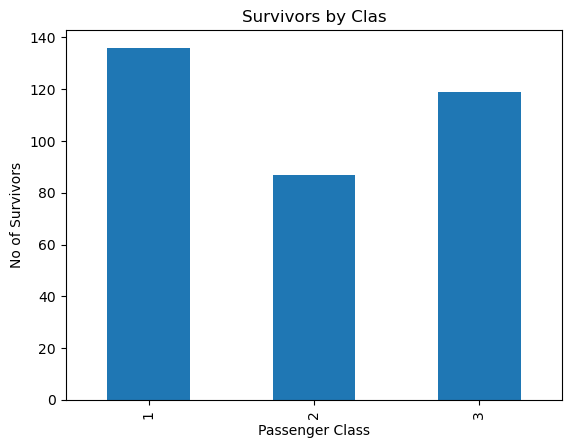

In [5]:
# (D)

survivors_byclass = df[df['survived']==1]['pclass'].value_counts()
print(survivors_byclass)

survivors_byclass.sort_index().plot(kind='bar',title='Survivors by Clas')
plt.xlabel("Passenger Class")
plt.ylabel("No of Survivors")
plt.show()

In [6]:
# (E)

age_stats_gender = df.groupby('sex')['age'].describe()
print(age_stats_gender)

        count       mean        std   min   25%   50%   75%   max
sex                                                              
female  261.0  27.915709  14.110146  0.75  18.0  27.0  37.0  63.0
male    453.0  30.726645  14.678201  0.42  21.0  29.0  39.0  80.0


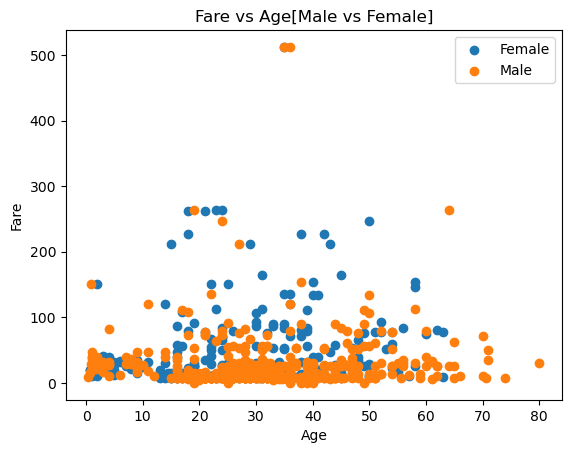

In [7]:
# (F)

plt.scatter(df[df['sex']=='female']['age'],df[df['sex']=='female']['fare'],label='Female')
plt.scatter(df[df['sex']=='male']['age'],df[df['sex']=='male']['fare'],label='Male')
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Fare vs Age[Male vs Female]")
plt.legend()
plt.show()

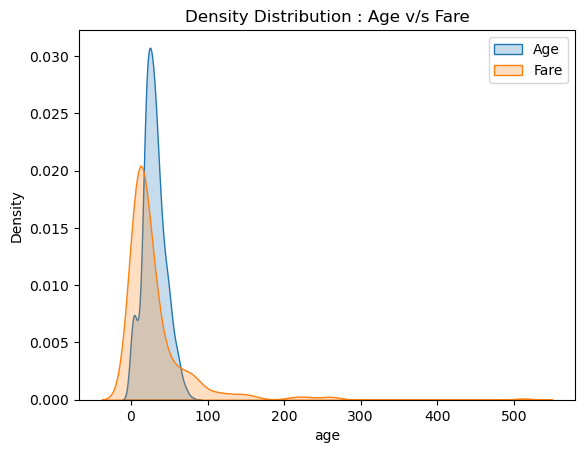

In [8]:
# (g)
sns.kdeplot(df['age'].dropna(),label='Age',fill=True)
sns.kdeplot(df['fare'] ,label='Fare',fill=True)
plt.title("Density Distribution : Age v/s Fare")
plt.legend()
plt.show()

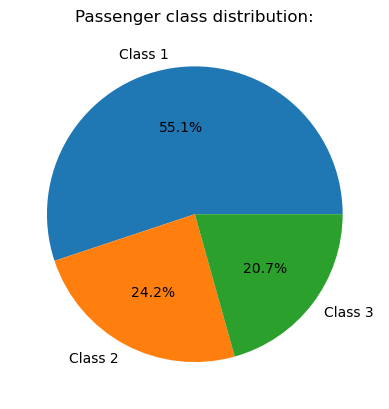

In [9]:
# (h)
class_counts = df["pclass"].value_counts()
plt.pie(class_counts,labels=["Class 1", "Class 2","Class 3"],autopct="%1.1F%%")
plt.title("Passenger class distribution:")
plt.show()

In [10]:
# (i)
# Survival rate per class
survival_rate = df.groupby('pclass')['survived'].mean() * 100
print("Survival Percentage by Class:\n", survival_rate)

Survival Percentage by Class:
 pclass
1    62.962963
2    47.282609
3    24.236253
Name: survived, dtype: float64
